In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

In [31]:
from google.colab import files
uploaded = files.upload()

Saving credit_risk.csv to credit_risk (2).csv


In [32]:
df = pd.read_csv("credit_risk.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [34]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [35]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [36]:
df.duplicated().sum()

np.int64(0)

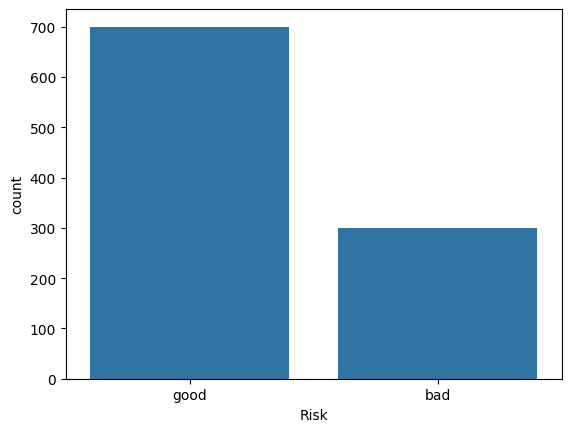

In [37]:
sns.countplot(x='Risk', data=df)
plt.show()

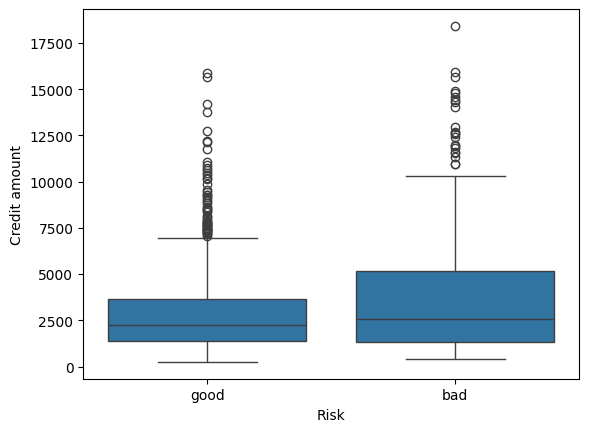

In [38]:
sns.boxplot(x='Risk', y='Credit amount', data=df)
plt.show()

<Axes: ylabel='count'>

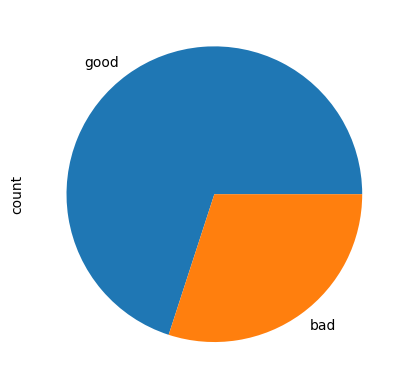

In [39]:
df['Risk'].value_counts().plot(kind='pie')

In [40]:
#for col in df.columns:
    #if df[col].dtype == 'object':
        #df[col] = pd.factorize(df[col])[0].astype(float)

#print(df.dtypes)

In [41]:
#sns.heatmap(df.corr(), cmap='coolwarm')
#plt.show()

In [42]:
df['Age_Group'] = pd.cut(df['Age'], bins=[18,25,35,50,70], labels=[1,2,3,4])

In [43]:
df['Age_Group']

,Age_Group
0,4
1,1
2,3
3,3
4,4
...,...
995,2
996,3
997,3
998,1


array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Job'}>,
        <Axes: title={'center': 'Credit amount'}>],
       [<Axes: title={'center': 'Duration'}>, <Axes: >]], dtype=object)

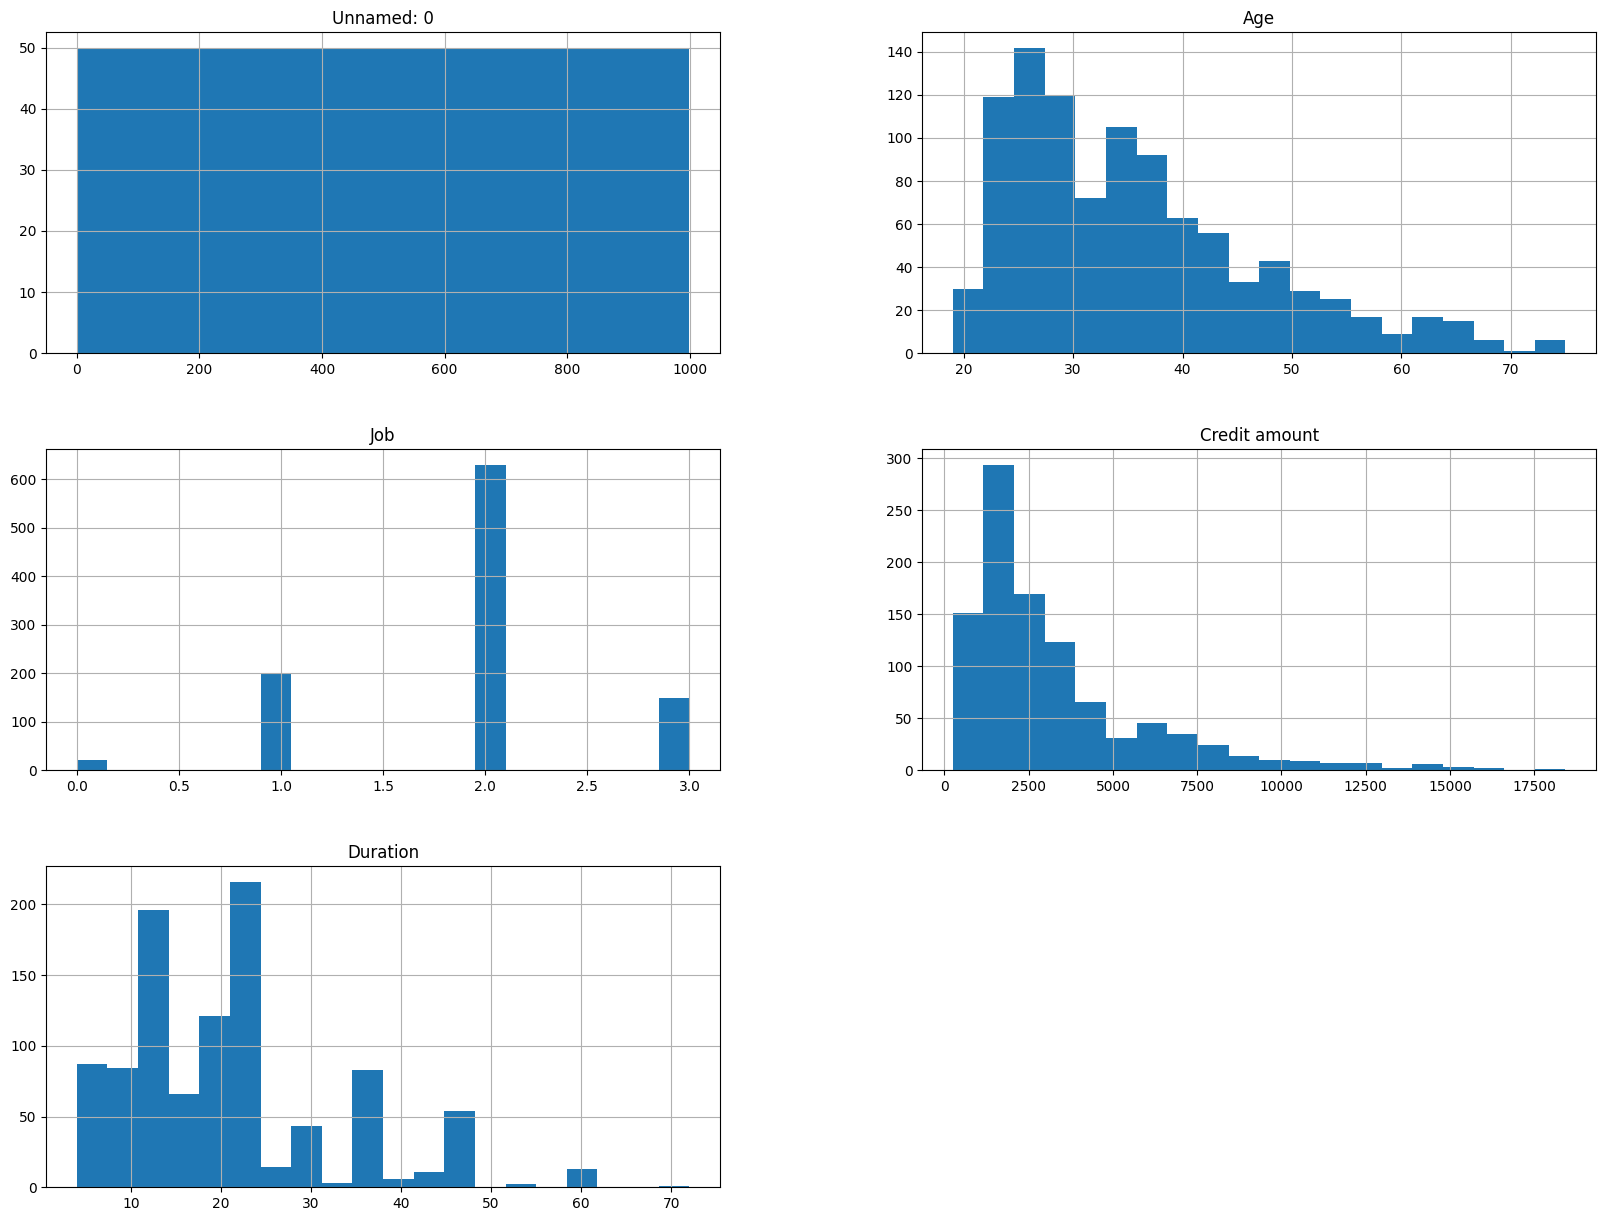

In [44]:
df.hist(bins=20,figsize=(20,15))

In [45]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [46]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [47]:
X = df.drop('Risk', axis=1)
y = df['Risk']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


/usr/local/lib/python3.12/dist-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)


In [50]:
y_train.value_counts()

,count
Risk,
1,560
0,240


In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

In [52]:
y_train_smote.value_counts()

,count
Risk,
1,560
0,560


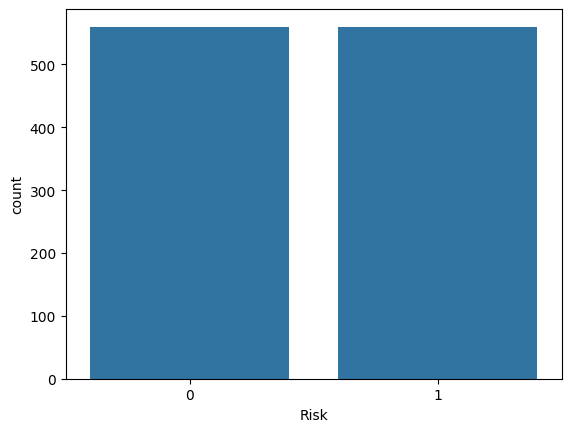

In [53]:

plt.Figure(figsize=(7,5))
sns.countplot(x = y_train_smote)
plt.show()

In [56]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X_train_smote, y_train_smote)
y_pred = LR.predict(X_test)
print("LR-accuracy:", accuracy_score(y_test,y_pred)*100)

LR-accuracy: 68.0


In [57]:
print("LR-cm:", confusion_matrix(y_test,y_pred))
print("LR-cr:", classification_report(y_test,y_pred))

LR-cm: [[46 14]
 [50 90]]
LR-cr:               precision    recall  f1-score   support

           0       0.48      0.77      0.59        60
           1       0.87      0.64      0.74       140

    accuracy                           0.68       200
   macro avg       0.67      0.70      0.66       200
weighted avg       0.75      0.68      0.69       200



In [58]:
from lightgbm import LGBMClassifier
lgb = LGBMClassifier()
lgb.fit(X_train_smote, y_train_smote)
y_pred = lgb.predict(X_test)

print("LGB-accuracy:", accuracy_score(y_test,y_pred)*100)

[LightGBM] [Info] Number of positive: 560, number of negative: 560
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1224
[LightGBM] [Info] Number of data points in the train set: 1120, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGB-accuracy: 78.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [59]:
print("LGBM-cm:", confusion_matrix(y_test,y_pred))
print("LGBM-cr:", classification_report(y_test,y_pred))

LGBM-cm: [[ 36  24]
 [ 20 120]]
LGBM-cr:               precision    recall  f1-score   support

           0       0.64      0.60      0.62        60
           1       0.83      0.86      0.85       140

    accuracy                           0.78       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.78      0.78      0.78       200



In [60]:
risk_prob_lr = LR.predict_proba(X_test)[:,1]

In [61]:
risk_prob_lgbm = lgb.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [62]:
def risk_level(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

In [63]:

results = pd.DataFrame({
    'Actual': y_test,
    'Risk Probability': risk_prob_lgbm
})

results['Risk Level'] = results['Risk Probability'].apply(risk_level)

print(results.head(10))

     Actual  Risk Probability   Risk Level
977       1          0.990735    High Risk
735       1          0.795820    High Risk
615       1          0.704777    High Risk
413       1          0.887412    High Risk
563       0          0.395865  Medium Risk
27        1          0.941375    High Risk
514       1          0.997621    High Risk
624       0          0.775249    High Risk
475       0          0.037336     Low Risk
991       1          0.935818    High Risk


In [64]:

for prob in risk_prob_lgbm[:5]:
    if prob > 0.60:
        print("Reject Loan")
    else:
        print("Approve Loan")

Reject Loan
Reject Loan
Reject Loan
Reject Loan
Approve Loan
